# Faz 3a — YOLO-Seg Veri Hazırlık (Poligon)
### bbox→poligon proxy · seg_data/yolo_seg PNG+poligon export

Bu notebook **Faz3b_YOLOSeg_Colab_Kaggle.ipynb** çalıştırılmadan önce bir kez çalıştırılır.

**Önkoşul:** `Faz3a_VeriHazirlik_YOLO.ipynb` daha önce çalıştırılmış olmalı —
bu notebook ondan `manifest.csv` ve `splits.csv` dosyalarını **yeniden kullanır**,
yeniden üretmez.

**Segmentasyon ground truth kaynağı:**
Bilgi.xlsx'te piksel-seviyeli organ/lezyon konturu (gerçek maske) yoktur —
yalnızca Bounding Box ve Boundary Slice annotasyonları vardır. Kullanıcı kararı:
**bounding box'un kendisi hastalığın 2D sınırını temsil eder**, bu nedenle
segmentasyon poligonu doğrudan bbox'un 4 köşesinden (dikdörtgen) üretilir.
TotalSegmentator / pseudo-mask gibi ek bir bağımlılık **kullanılmaz**.

| Adım | Açıklama | Süre |
|------|----------|------|
| manifest/splits kontrolü | Faz3a'dan devralınır (yeniden üretilmez) | <1 dk |
| yolo_seg (1 fold) | PNG + poligon label export | ~30–90 dk |
| yolo_seg (5 fold) | Tüm foldlar | ~3–6 saat |

> **Not:** Görüntüler Faz3a'daki `det_data` ile birebir aynı pencerelemeyle üretilir;
> tek fark etiket formatıdır (bbox txt → poligon txt).

---
## 0. Ortam Tespiti

In [1]:
import os, sys, subprocess
from pathlib import Path

IS_KAGGLE = os.path.exists('/kaggle/working')
IS_COLAB  = not IS_KAGGLE and os.path.exists('/content')
IS_LOCAL  = not IS_KAGGLE and not IS_COLAB

env_name = 'Kaggle' if IS_KAGGLE else 'Colab' if IS_COLAB else 'Local'
print(f'Ortam : {env_name}')

Ortam : Local


---
## 1. Ortam Kurulumu (Colab için)

In [2]:
if IS_COLAB:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'kaggle'], check=True)
    try:
        from google.colab import userdata
        os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
        os.environ['KAGGLE_KEY']      = userdata.get('KAGGLE_KEY')
        print('Kaggle kimlik bilgileri Colab Secrets\'tan yüklendi')
    except Exception:
        from google.colab import files
        import json as _j, shutil as _sh
        print('kaggle.json dosyasını seçin:')
        _up = files.upload()
        _kp = Path.home() / '.kaggle' / 'kaggle.json'
        _kp.parent.mkdir(parents=True, exist_ok=True)
        for fname in _up:
            _sh.move(fname, str(_kp))
        os.chmod(str(_kp), 0o600)
        _kd = _j.loads(_kp.read_text())
        os.environ['KAGGLE_USERNAME'] = _kd['username']
        os.environ['KAGGLE_KEY']      = _kd['key']
        print('kaggle.json yüklendi')

    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    print('Google Drive bağlandı')
else:
    print('Kaggle/Local ortamı — Colab kurulumu atlandı')

Kaggle/Local ortamı — Colab kurulumu atlandı


---
## 2. Kütüphane Kurulumu

In [3]:
print('Kütüphaneler kuruluyor...')
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q',
     'pandas', 'numpy', 'tqdm', 'pillow', 'openpyxl',
     'pydicom', 'scikit-learn', 'python-dotenv'],
    check=True
)
import importlib; importlib.invalidate_caches()

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
print('Kütüphaneler hazır ✓')

Kütüphaneler kuruluyor...
Kütüphaneler hazır ✓


---
## 3. Konfigürasyon

In [4]:
import os, json
from pathlib import Path
from typing import List

# ─── Kullanıcı Ayarları ───────────────────────────────────────────────────
KAGGLE_DATASET_SLUG = 'abdomen-acikveri'
KAGGLE_DATASET_ID   = 'ramazan2020/abdomen-acikveri'
GITHUB_URL          = 'https://github.com/ramazan2020/abdomen1.git'

FOLD             = 0      # Varsayılan fold (EXPORT_ALL_FOLDS=False ise bu fold export edilir)
N_FOLDS          = 5      # Toplam fold sayısı
EXPORT_ALL_FOLDS = False   # True: tüm 5 fold export edilir
# ─────────────────────────────────────────────────────────────────────────

SUPER_CLASSES: List[str] = [
    'acute_cholecystitis', 'kidney_ureter_stone', 'acute_pancreatitis',
    'aortic_aneurysm_dissection', 'acute_appendicitis', 'acute_diverticulitis',
]

if IS_KAGGLE:
    DATA_DIR   = Path('/kaggle/input') / KAGGLE_DATASET_SLUG
    WORK_DIR   = Path('/kaggle/working')

elif IS_COLAB:
    DATA_DIR   = Path('/content/kaggle_data')
    WORK_DIR   = Path('/content')

elif IS_LOCAL:
    try:
        from dotenv import load_dotenv; load_dotenv()
    except ImportError:
        pass
    _proje   = Path(os.environ.get('TR_ABDOMEN_PROJE',  r'D:/makale-pdf/Proje'))
    DATA_DIR = Path(os.environ.get('TR_ABDOMEN_BASE',   str(_proje / 'abdomen')))
    WORK_DIR = Path(os.environ.get('ABDOMEN_OUT_DIR',   str(_proje / 'outputs')))

SPLIT_DIR        = Path(os.environ.get('ABDOMEN_SPLIT_DIR',    str(WORK_DIR / 'splits')))
SEG_YOLO_DATA_DIR = Path(os.environ.get('ABDOMEN_SEG_YOLO_DIR', str(WORK_DIR / 'seg_data' / 'yolo_seg')))

SEG_YOLO_DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f'Ortam            : {env_name}')
print(f'DATA_DIR         : {DATA_DIR}  (var={DATA_DIR.exists()})')
print(f'WORK_DIR         : {WORK_DIR}  (var={WORK_DIR.exists()})')
print(f'SPLIT_DIR        : {SPLIT_DIR}  (var={SPLIT_DIR.exists()})')
print(f'SEG_YOLO_DATA_DIR: {SEG_YOLO_DATA_DIR}  (var={SEG_YOLO_DATA_DIR.exists()})')

if not DATA_DIR.exists():
    raise FileNotFoundError(f'DATA_DIR bulunamadı: {DATA_DIR}')

Ortam            : Local
DATA_DIR         : D:\makale-pdf\Proje\abdomen  (var=True)
WORK_DIR         : D:\makale-pdf\Proje\outputs  (var=True)
SPLIT_DIR        : D:\makale-pdf\Proje\outputs\splits  (var=True)
SEG_YOLO_DATA_DIR: D:\makale-pdf\Proje\outputs\seg_data\yolo_seg  (var=True)


---
## 4. GitHub Repo / Local src

In [5]:
if IS_LOCAL:
    REPO_DIR = Path('.').resolve()
    print(f'Local: src/ kullanılıyor → {REPO_DIR / "src"}')
else:
    REPO_DIR = WORK_DIR / 'abdomen1'
    if not (REPO_DIR / '.git').exists():
        print(f'Klonlanıyor: {GITHUB_URL}')
        subprocess.run(
            ['git', 'clone', '--depth=1', GITHUB_URL, str(REPO_DIR)],
            check=True
        )
    else:
        print('Repo mevcut, güncelleniyor...')
        subprocess.run(['git', '-C', str(REPO_DIR), 'pull', '--ff-only'],
                       capture_output=True)

if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

# env var'larını src'nin görebileceği şekilde ayarla
os.environ.setdefault('ABDOMEN_SPLIT_DIR',     str(SPLIT_DIR))
os.environ.setdefault('ABDOMEN_SEG_YOLO_DIR',  str(SEG_YOLO_DATA_DIR))
os.environ.setdefault('ABDOMEN_BILGI_XLSX',    str(DATA_DIR / 'Bilgi.xlsx'))

print(f'Repo : {REPO_DIR}')
print(f'sys.path[0] = {sys.path[0]}')

Local: src/ kullanılıyor → D:\makale-pdf\Proje\code\src
Repo : D:\makale-pdf\Proje\code
sys.path[0] = D:\makale-pdf\Proje\code


---
## 5. manifest.csv / splits.csv Kontrolü

Bu dosyalar **Faz3a_VeriHazirlik_YOLO.ipynb** tarafından üretilir. Burada
yeniden üretilmez — sadece varlığı doğrulanır (split mantığının her iki
notebook'ta birbirinden sapmasını önlemek için).

In [6]:
_manifest_csv = SPLIT_DIR / 'manifest.csv'
_splits_csv   = SPLIT_DIR / 'splits.csv'

if not _manifest_csv.exists() or not _splits_csv.exists():
    raise FileNotFoundError(
        'manifest.csv / splits.csv bulunamadı.\n'
        'Önce Faz3a_VeriHazirlik_YOLO.ipynb dosyasını çalıştırın — bu notebook '
        'onun ürettiği split\'leri yeniden kullanır.'
    )

manifest_df = pd.read_csv(_manifest_csv)
splits_df   = pd.read_csv(_splits_csv)
print(f'manifest.csv ✓  {len(manifest_df):,} satır · {manifest_df["case"].nunique()} vaka')
print(f'splits.csv   ✓  {len(splits_df):,} vaka (train+val havuzu)')

for f in range(N_FOLDS):
    _tr = SPLIT_DIR / f'fold{f}_train.csv'
    _vl = SPLIT_DIR / f'fold{f}_val.csv'
    if not _tr.exists() or not _vl.exists():
        raise FileNotFoundError(
            f'fold{f}_train.csv / fold{f}_val.csv eksik — Faz3a_VeriHazirlik_YOLO.ipynb\'u çalıştırın.'
        )
print(f'Tüm {N_FOLDS} fold split dosyası mevcut ✓')

manifest.csv ✓  39,268 satır · 1092 vaka
splits.csv   ✓  928 vaka (train+val havuzu)
Tüm 5 fold split dosyası mevcut ✓


---
## 6. YOLO-Seg yolo_seg — PNG + Poligon Export

`EXPORT_ALL_FOLDS = True` → 5 fold birden export edilir.
`EXPORT_ALL_FOLDS = False` → yalnızca `FOLD` değişkenindeki fold export edilir.

Etiket formatı: `cls x1 y1 x2 y2 x3 y3 x4 y4` (normalize, bbox'ın 4 köşesi).

In [7]:
import time
from src.yolo_seg import export_yolo_seg_dataset

folds_to_export = list(range(N_FOLDS)) if EXPORT_ALL_FOLDS else [FOLD]
print(f'Export edilecek foldlar : {folds_to_export}')
print(f'Hedef dizin             : {SEG_YOLO_DATA_DIR}')
print(f'Negatif vakalar dahil   : True (boş label → false positive bastırma)')
print()

for fold in folds_to_export:
    fold_dir  = SEG_YOLO_DATA_DIR / f'fold{fold}'
    train_img = fold_dir / 'images' / 'train'
    val_img   = fold_dir / 'images' / 'val'

    n_train = len(list(train_img.glob('*.png'))) if train_img.exists() else 0
    n_val   = len(list(val_img.glob('*.png')))   if val_img.exists()   else 0

    if n_train > 0:
        print(f'Fold {fold}: mevcut ✓  ({n_train:,} train · {n_val:,} val PNG)')
    else:
        print(f'Fold {fold}: oluşturuluyor...')
        t0 = time.time()
        export_yolo_seg_dataset(
            fold=fold,
            out_root=SEG_YOLO_DATA_DIR,
            include_val_negatives=False,
            bbox_only=True,
            include_train_negatives=True,
        )
        elapsed = time.time() - t0
        n_train = len(list(train_img.glob('*.png'))) if train_img.exists() else 0
        n_val   = len(list(val_img.glob('*.png')))   if val_img.exists()   else 0
        print(f'Fold {fold}: oluşturuldu ✓  ({n_train:,} train · {n_val:,} val PNG — {elapsed/60:.1f} dk)')

Export edilecek foldlar : [0]
Hedef dizin             : D:\makale-pdf\Proje\outputs\seg_data\yolo_seg
Negatif vakalar dahil   : True (boş label → false positive bastırma)

Fold 0: oluşturuluyor...
BBox filtresi: 7,303 bbox'sız satır dışlandı → 31,965 kesit işlenecek
Negatif vakalar: 161 vaka, 1,855 dilim → train (boş label)


YOLO-seg fold0: 100%|██████████| 28414/28414 [06:26<00:00, 73.45it/s] 


Fold 0: oluşturuldu ✓  (23,328 train · 5,086 val PNG — 6.5 dk)


---
## 7. Poligon Örnek Doğrulama (Görsel Kontrol)

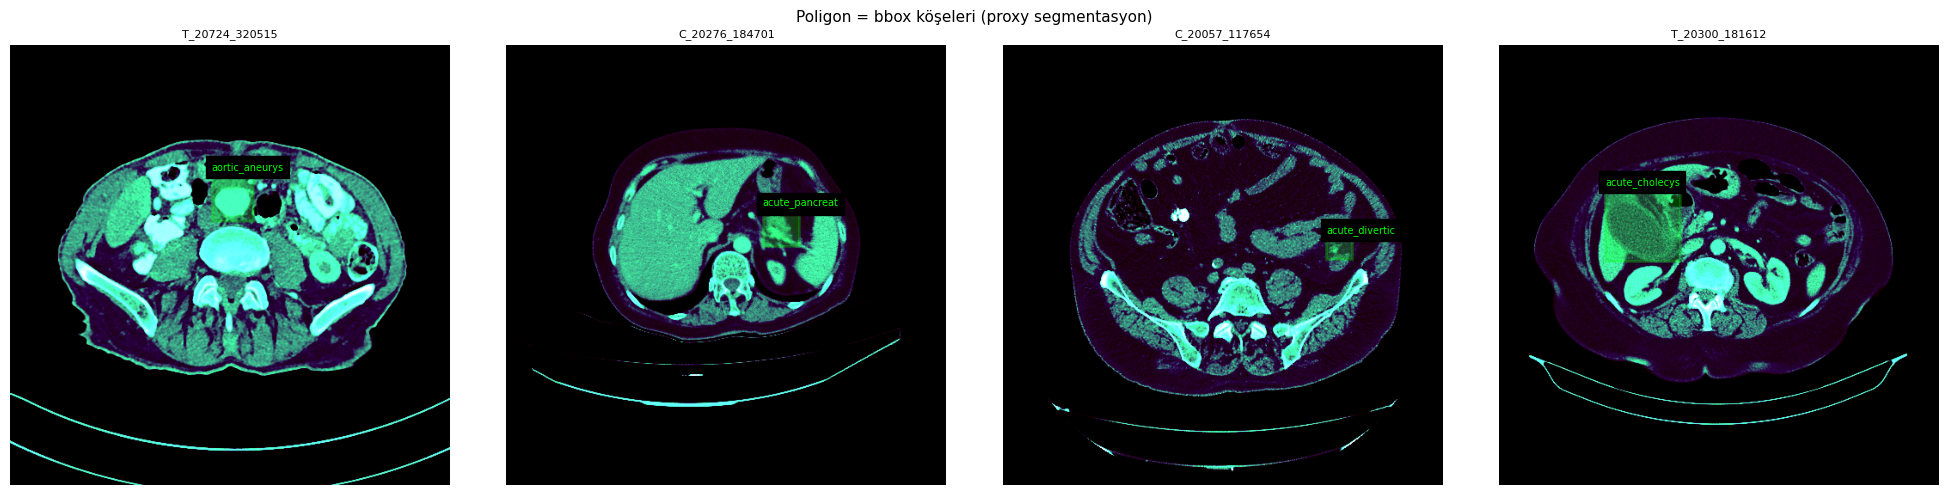

In [8]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
%matplotlib inline

_fold_dir   = SEG_YOLO_DATA_DIR / f'fold{FOLD}'
_train_img  = _fold_dir / 'images' / 'train'
_train_lbl  = _fold_dir / 'labels' / 'train'

_annotated = [p for p in sorted(_train_img.glob('*.png'))
              if (_train_lbl / (p.stem + '.txt')).exists()
              and (_train_lbl / (p.stem + '.txt')).stat().st_size > 0]

random.seed(42)
_samples = random.sample(_annotated, min(4, len(_annotated)))

fig, axes = plt.subplots(1, len(_samples), figsize=(5*len(_samples), 5))
if len(_samples) == 1: axes = [axes]

for ax, ip in zip(axes, _samples):
    img = np.array(Image.open(ip).convert('RGB'))
    h, w = img.shape[:2]
    ax.imshow(img)
    for line in (_train_lbl / (ip.stem + '.txt')).read_text().strip().splitlines():
        parts = line.split()
        cls = int(parts[0])
        coords = list(map(float, parts[1:]))
        xs = [coords[i]*w for i in range(0, len(coords), 2)]
        ys = [coords[i]*h for i in range(1, len(coords), 2)]
        poly = mpatches.Polygon(list(zip(xs, ys)), closed=True,
                                 edgecolor='lime', facecolor='lime', alpha=0.25, linewidth=2)
        ax.add_patch(poly)
        ax.text(xs[0], ys[0]-4, SUPER_CLASSES[cls][:14], color='lime', fontsize=7,
                backgroundcolor='black')
    ax.set_title(ip.stem, fontsize=8)
    ax.axis('off')

plt.suptitle('Poligon = bbox köşeleri (proxy segmentasyon)', fontsize=11)
plt.tight_layout()
plt.show()

---
## 8. Doğrulama

In [9]:
print('=' * 52)
print(f'  Faz 3a (Seg) — Veri Hazırlık Özeti')
print('=' * 52)

all_ok = True
for fold in range(N_FOLDS):
    train_img = SEG_YOLO_DATA_DIR / f'fold{fold}' / 'images' / 'train'
    val_img   = SEG_YOLO_DATA_DIR / f'fold{fold}' / 'images' / 'val'
    n_tr = len(list(train_img.glob('*.png'))) if train_img.exists() else 0
    n_vl = len(list(val_img.glob('*.png')))   if val_img.exists()   else 0
    ok = n_tr > 0
    if not ok:
        all_ok = False
    print(f'  fold{fold}: {n_tr:>6,} train · {n_vl:>5,} val  {"✓" if ok else "✗ EKSİK"}')

print('=' * 52)
if all_ok:
    print('  Hazır foldlar mevcut — Faz3b_YOLOSeg_Colab_Kaggle.ipynb çalıştırılabilir ✓')
else:
    print('  Bazı foldlar eksik — cell_seg_export\'u tekrar çalıştırın (EXPORT_ALL_FOLDS=True ile)')

  Faz 3a (Seg) — Veri Hazırlık Özeti
  fold0: 23,328 train · 5,086 val  ✓
  fold1:      0 train ·     0 val  ✗ EKSİK
  fold2:      0 train ·     0 val  ✗ EKSİK
  fold3:      0 train ·     0 val  ✗ EKSİK
  fold4:      0 train ·     0 val  ✗ EKSİK
  Bazı foldlar eksik — cell_seg_export'u tekrar çalıştırın (EXPORT_ALL_FOLDS=True ile)
